## Model1 train

A continuación, se implementa el flujo de entrenamiento para el modelo presentado en la sección anterior. Aunque este modelo es conceptualmente reducido y simple como para generar texto fluido o ser utilizable en producción, el objetivo central es asimilar la estructura y la anatomía del código de entrenamiento.

El entrenamiento de Large Language Models (LLMs) a gran escala sigue este mismo procedimiento fundamental: cambian la complejidad computacional, el volumen de datos y el tiempo de cálculo, pero la estructura del código esencial es la misma. Durante el proceso se observa cómo se entrena la matriz de embeddings y se reconocen todos los procedimientos estándar del deep learning y el descenso de gradiente.

In [1]:
## Cargar Librerias

### Cargar Librerias

In [43]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# Componentes de PyTorch
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

# Gráficos vectoriales
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


## Cargar tokenizador

In [46]:
# Tokenizador de GPT-2
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

### Uso de GPU

In [48]:
# Usar la GPU para mayor velocidad
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Hyperparametros

In [49]:
# Hiperparámetros de los datos
seq_len = 8  # Longitud del contexto
stride = 2

# Hiperparámetros del modelo
embed_dim = 2**6  # 64

# Hiperparámetros de entrenamiento
batch_size = 64

### Tomar Data

In [50]:
# Tokenizar el texto y convertirlo en un tensor
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (45295 > 1024). Running this sequence through the model will result in indexing errors


45295

> **Advertencia de longitud de secuencia:**
> Esta advertencia indica que la secuencia de tokens generada a partir del texto excede la capacidad máxima del tokenizador (ventana de contexto de **1024 tokens** de GPT-2).
> El tokenizador procesa el texto completo sin truncarlo por defecto al llamar a `encode()`, pero cualquier secuencia con más de 1024 tokens superará el límite de atención posicional nativo del modelo base si se pasa directamente sin segmentar.

---

**DataLoader**

In [51]:
# Crear una clase para el dataset (nota: la división en lotes la realiza el DataLoader, no el dataset)
class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # Inicializar
    self.inputs  = []
    self.targets = []

    # Secuencias superpuestas de longitud seq_len
    for i in range(0, len(tokens) - seq_len, stride):

      # Obtener tokens y agregarlos a las listas
      self.inputs.append( tokens[i   : i+seq_len])   # La idea es procesar estos tokens
      self.targets.append(tokens[i+1 : i+seq_len+1]) # Y que prediga los siguientes tokens

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]

In [53]:
# Crear una instancia!
token_dataset = TokenDataset(tmTokens, seq_len, stride)

token_dataloader = DataLoader(token_dataset, batch_size=batch_size, shuffle=True)
next(iter(token_dataloader))


[tensor([[ 3589,    13,   887,    11,   355,   345,   198, 16275],
         [   13,   564,   250, 24446,   345, 27606,    11,   447],
         [ 5276,   391,   198, 18108,   257,  1049,  1730,   517],
         [ 1276, 13796,    11,   373,  1863,   262,  3862,    12],
         [  286,  2000,    11,   314,  1816,   866,   284,   262],
         [  550,   198,  1462,   307, 33626,    13,   314,   550],
         [  262, 33093,  6899,    11,   257,   890, 15604,  6578],
         [  290,   355,   198, 34191,   287,   511,   835,    11],
         [  257,  5019,  4020,  2402,   663,  5046,    13,  7831],
         [  396,   198,    83,  2228,   284, 26958,   262, 12097],
         [ 2174,    11,   257,   198,  3919,   271,  5321, 39610],
         [ 6766,  6348, 26083,    11,   290,   262,  1657,   286],
         [   11,   314,  2227,   262,  3862, 10850,    11,   290],
         [ 1218, 14078,   373,   477,  2642,    13,   383, 20390],
         [  290,   788,   314,   714,  1254,   606, 13885,   5

## El modelo

In [54]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # Matriz de incrustación (embedding)
    self.embedding = nn.Embedding(tokenizer.vocab_size, embed_dim)

    # Capa (lineal) de embedding a salida
    self.gelu = nn.GELU()
    self.finalLinear = nn.Linear(embed_dim, tokenizer.vocab_size)

  def forward(self, tokx):

    # Propagación hacia adelante (forward pass)
    x = self.embedding(tokx) # [batch, token, embeddings]
    x = self.gelu(x)
    x = self.finalLinear(x) # [embeddings, vocab]

    # Retornar log-softmax
    return F.log_softmax(x, dim=-1)

  def generate(self, tokx, n_new_tokens=30):
    # Prácticamente igual que en DULM_buildGPT_model1 pero sin comentarios
    for _ in range(n_new_tokens):
      x = self(tokx)
      x = x[:, -1, :]
      probs = torch.exp(x) # Deshacer el logaritmo pero mantener el softmax (usamos el exponente natural que es la inversa del logaritmo natural)
      nextToken = torch.multinomial(probs, num_samples=1)
      tokx = torch.cat((tokx, nextToken), dim=1) # Concatenamos el nuevo token en la lista existente de los tokens
    return tokx

$$\text{CrossEntropyLoss} = \text{Log-Softmax} + \text{NLLLoss}$$

* **`nn.NLLLoss`:** Requiere que el modelo entregue **`log_softmax`** en el `forward` (como en tu código).
* **`nn.CrossEntropyLoss`:** Requiere **logits directos** (sin activación previa), porque ya calcula `log_softmax` internamente.

> Como el `forward` termina con `F.log_softmax(x)`, se debe usar **`nn.NLLLoss()`**. Usar `CrossEntropyLoss` aquí aplicaría softmax dos veces por error.

## Iscpeccionar la salida del modelo (Output)

In [55]:
model = Model()
X, y = token_dataset[4]
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape) # Confirmar que torch.sum(torch.exp(out)) == 1

torch.Size([8])
torch.Size([8])
torch.Size([8, 50257])


In [56]:
torch.sum(torch.exp(out)) # Suman 8 porque es por la cantidad de filas

tensor(8.0000, grad_fn=<SumBackward0>)

La operación `torch.exp(out)` aplica la función exponencial ($e^x$), que es la inversa directa del logaritmo natural ($\ln$):

$$e^{\ln(p)} = p$$

* **De log-probabilidades a probabilidades:** El modelo retorna $\ln(P)$, por lo que `torch.exp` revierte el logaritmo y recupera las probabilidades directas del **Softmax estándar**.
* **Distribución por token:** Para cada uno de los tokens de la secuencia, la suma de probabilidades a lo largo de todo el vocabulario es igual a **1** ($\sum p_i = 1$).
* **Suma total:** Como el tensor contiene una secuencia de 8 tokens (`seq_len = 8`), sumar todos los elementos del tensor devuelve exactamente **8** (1 por cada fila o posición de la secuencia).

In [57]:
print(X)
print(y)
print(torch.argmax(out))

tensor([ 1677, 13246,    38,   412, 39453,  3439, 17202,   628])
tensor([13246,    38,   412, 39453,  3439, 17202,   628,   628])
tensor(318904)


## Preparado para el Entrenamiento

In [58]:
# Enviar el modelo a la GPU
model = model.to(device)

In [60]:
# Crear las funciones de pérdida y el optimizador
loss_function = nn.NLLLoss().to(device) # Esta es la función de error que espera log-softmax
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01) # es decir adawn con su weight_decay

In [15]:
# inspeccionar si la funcion de error esta funcionando

In [61]:
# Comprobar la función de pérdida con los tamaños
X, y = next(iter(token_dataloader))
log_probs = model(X.to(device))

print(f'El tamaño de entrada del modelo es:   {X.shape}')
print(f'El tamaño de salida del modelo es:   {log_probs.shape}')
print(f'El tamaño de los tokens objetivo es: {y.shape}')

# Error de dimensiones esperado...
loss_function(log_probs[:, :-1, :], y[:, 1:].to(device))

El tamaño de entrada del modelo es:   torch.Size([64, 8])
El tamaño de salida del modelo es:   torch.Size([64, 8, 50257])
El tamaño de los tokens objetivo es: torch.Size([64, 8])


RuntimeError: Expected target size [64, 50257], got [64, 7]

### ¿Por qué ocurre el error?

El error se debe a un **desajuste en el orden de las dimensiones**:

* **Salida del modelo:** Tiene la forma `(Batch, Secuencia, Vocabulario)` $\rightarrow$ `(64, 7, 50257)`.
* **Lo que exige `nn.NLLLoss`:** Para datos secuenciales 3D, PyTorch requiere que la dimensión de las clases (el vocabulario) esté en la **segunda posición**: `(Batch, Vocabulario, Secuencia)` $\rightarrow$ `(64, 50257, 7)`.

---

### ¿Cómo se interpreta?

PyTorch intenta emparejar la dimensión de clases con la posición 1 del tensor. Al ver ahí un $7$ (la longitud de secuencia) en lugar de $50257$ (el tamaño del vocabulario), asume que solo existen 7 clases posibles, fallando inmediatamente al encontrar índices de palabras mayores a 6.

---

### Dos formas de solucionarlo

1. **Permutar dimensiones:** Cambiar de lugar la dimensión de la secuencia con la del vocabulario para que el vocabulario quede en la posición central.
2. **Aplanar los tensores:** Reestructurar las predicciones a una matriz 2D `(Tokens totales, Vocabulario)` y los objetivos a un vector 1D `(Tokens totales)`.

## Solución: Reestructurar (*reshape*) la salida

La función de pérdida (`nn.NLLLoss`) no procesa directamente el tensor en formato `(Batch, Secuencia, Vocabulario)`. Para solucionarlo, aplanamos las dimensiones del lote y de la secuencia en una sola:

* **De tensor 3D a matriz 2D:** Convertimos las predicciones `(64, 7, 50257)` en una matriz bidimensional `(64 × 7, 50257)` $\rightarrow$ `(448, 50257)`. Cada fila representa un token individual con la distribución de probabilidades de todo el vocabulario.
* **Vector 1D para los objetivos:** Aplanamos los targets `(64, 7)` en un único vector continuo de `448` elementos, emparejando cada predicción con su etiqueta real correspondiente.

In [62]:
# Preocuparse por este reshaping depende del modelo que se utilice

# En inferencia autoregresiva solo se evalúa el último token, pero en entrenamiento causal
# y en modelos bidireccionales (como BERT) se calcula la pérdida sobre todos los tokens de la secuencia.

# Aplanar a [batch*token, vocab]
log_probs_flat = log_probs.reshape(-1, log_probs.shape[-1])

# Aplanar a un vector
y_flat = y.reshape(-1)

print(f'El tamaño de salida del modelo es:   {log_probs_flat.shape}')
print(f'El tamaño de los tokens objetivo es: {y_flat.shape}')

# Ahora calcular la pérdida
loss = loss_function(log_probs_flat, y_flat.to(device))
print('\nPérdida:', loss)

El tamaño de salida del modelo es:   torch.Size([512, 50257])
El tamaño de los tokens objetivo es: torch.Size([512])

Pérdida: tensor(10.8746, device='cuda:0', grad_fn=<NllLossBackward0>)


### Vamos a generar algunos Textos

In [68]:
# Es lo que esperábamos al tratarse de un modelo no entrenado (pesos aleatorios)

# Texto generado por el modelo (comparar con el resultado post-entrenamiento)

# Debe ser un tensor con dimensión de lote (batch size = 1)
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# Generación de texto
Y = model.generate(startToks.to(device))
print(tokenizer.decode(Y[0].tolist()))

I thought the Eloi would be smarter than I had come into the tobacco frightfully oiled behind
came a discovery. I
in attitude to meet Richardson I must confess I baw


## Ahora vamos a Entrenar el Modelo

In [69]:
num_epochs = 25 # Recorriendo el libro en bucle 25 veces

# Inicializar las pérdidas
total_loss = np.zeros(num_epochs)

# Bucle de entrenamiento
for epoch in range(num_epochs):

  # Inicializar pérdidas de los lotes para acumular
  epoch_loss = 0

  # Iterar sobre los lotes en el data loader (X corresponde a batch x sequence_length y los targets a la secuencia desplazada)
  for X, y in token_dataloader:

    # Mover datos a la GPU
    X, y = X.to(device), y.to(device)

    # Limpiar gradientes previos
    optimizer.zero_grad()

    # Propagación hacia adelante (forward pass)
    log_probs = model(X)

    # Calcular las pérdidas sobre los tokens objetivo (reestructurados)
    # Nota: había un error en el código que causaba desalineación en los tokens objetivo. El código abajo es el correcto.
    log_probs_flat = log_probs.reshape(-1, log_probs.shape[-1]) # Tokens 0:N-1
    y_flat = y.reshape(-1) # Tokens 1:N
    loss = loss_function(log_probs_flat, y_flat)

    # Retropropagación (backprop)
    loss.backward()
    optimizer.step()

    # Sumar la pérdida del lote
    epoch_loss += loss.item()

  # Escalar por el número de lotes en este dataloader
  total_loss[epoch] = epoch_loss / len(token_dataloader)

  # Actualizar nuestro progreso :)
  if epoch % 2 == 0:
    print(f'Época {epoch+1:2} finalizada con pérdida {epoch_loss / len(token_dataloader):.4f}')

Época  1 finalizada con pérdida 3.0224
Época  3 finalizada con pérdida 3.0201
Época  5 finalizada con pérdida 3.0180
Época  7 finalizada con pérdida 3.0162
Época  9 finalizada con pérdida 3.0148
Época 11 finalizada con pérdida 3.0130
Época 13 finalizada con pérdida 3.0120
Época 15 finalizada con pérdida 3.0108
Época 17 finalizada con pérdida 3.0096
Época 19 finalizada con pérdida 3.0086
Época 21 finalizada con pérdida 3.0074
Época 23 finalizada con pérdida 3.0067
Época 25 finalizada con pérdida 3.0059


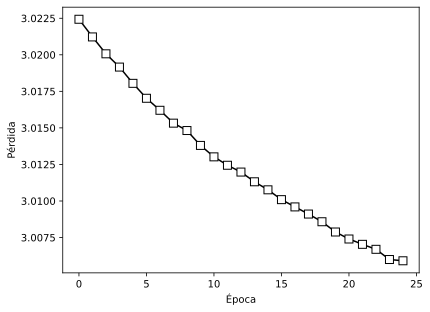

In [70]:
# Graficar las pérdidas
plt.plot(total_loss, 'ks-', markerfacecolor='w', markersize=8)
plt.gca().set(xlabel='Época', ylabel='Pérdida')
plt.show()

### Análisis de la curva de pérdida

* **Tendencia:** Descenso constante y monótono a lo largo de las 25 épocas, lo que confirma que el modelo está aprendiendo y optimizando los pesos correctamente.
* **Magnitud del cambio:** La reducción absoluta es muy pequeña: pasa de aproximadamente **3.0225 a 3.0060** ($\Delta \approx 0.0165$).
* **Comportamiento del modelo:** Al carecer de mecanismo de atención (solo tiene `Embedding` $\rightarrow$ `GELU` $\rightarrow$ `Linear`), el modelo no captura dependencias complejas entre tokens; principalmente aprende frecuencias globales de aparición de palabras (unigramas).
* **Estado de convergencia:** La pendiente se mantiene inclinada al final de la curva, lo que indica que aún no ha alcanzado una asíntota y podría seguir bajando con más épocas o una tasa de aprendizaje mayor.

In [72]:
# Pérdida teórica para pesos no entrenados (inicialización aleatoria)
-np.log(1 / tokenizer.vocab_size)

np.float64(10.82490511970208)

In [73]:
# Comprobar la salida del modelo para una secuencia de entrenamiento
print(tokenizer.decode(X[6].tolist()))
print(tokenizer.decode(y[6].tolist()))

 at me. At last,
hot
 me. At last,
hot and


In [100]:
# Y generar nuevos datos relacionados con el tema

# Debe ser un tensor con dimensión de lote (batch size = 1)
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# Generación de texto
Y = model.generate(startToks.to(device), n_new_tokens=80)
print(tokenizer.decode(Y[0].tolist()))

I thought the Eloi would be smarter than kept me by the ground the Time Machine?’s words, I
The machine. I
perhaps a second perhaps
s friend. I
the one of green of a certain journalist, of the midst of the sky. I had anticipated, a feeling of
would begrimaces I stood just rushed off the resemblance of our him. Then I presently
absolutely lonely again. “


In [75]:
# Cuando el texto inicial no se repite:
startToks, Y

(tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621]]),
 tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621,   262,
            198,   447,   247,    82,   511,  1310,   640,   379,   309,  9116,
           4623,   268, 21879,   540,  1021,   852,   198, 47779,   286,   198,
          10755,   428, 13542,  2402,   262,  8362,   198,   447,   250,  1722,
            314,   714,   670,  2402,   502,   379,   262,  2223,   286,   428,
            326, 14238,   282,    12,  1863,   198,  4993,    11,   373,  2391,
           6204,   510,   262,   198,  4188,   263,   434,   286,   198,  2375,
           1723,  2266,    12,  2118,    82,   922,   606,   198, 40539,   345,
           2497,   340,   550,  9569,   262,  4808, 38400,   944,   781]],
        device='cuda:0'))

In [78]:
# aca usamos un dot.replace para que no se confunda con el \n

In [76]:
# Usar esto:
print(tokenizer.decode(Y[0].tolist()).replace('\r', '\n'))

I thought the Eloi would be smarter than the
’s their little time at Tübingenetrable hand being
examination of
about this tendency upon the Story
“As I could work upon me at the action of this that pedestal- along
hand, was simply stood up the
queerment of
clearing red-rests good them
warn you saw it had viewed the _himself fl


In [77]:
  # Debido al retorno de carro (va al principio de la línea, no a la siguiente línea)
tokenizer.decode([201])

'\r'

### Conclusión y Aprendizajes Clave

Comprender este flujo mínimo otorga el control total sobre la anatomía del entrenamiento, sirviendo como punto de partida sólido para auditar, ajustar o interpretar modelos a cualquier escala.